Ce programme est une démonstration écrite pour illustrer les concepts de modèle generative. Son but est d'aider les étudiants à mieux comprendre les concepts de base des grands modèles de langage (LLM) en exécutant ce code. La conception de ce code met l'accent sur la clarté des concepts plutôt que sur l'efficacité de l'exécution. De plus, comme l'objectif est de transmettre des concepts, la syntaxe du programme ne sera pas expliquée en détail.

Avant de commencer, veuillez cliquer sur 'Fichier' dans la barre d'outils supérieure et sélectionner 'Enregistrer une copie dans Drive' pour travailler sur votre propre copie. Comme cette opération utilisera un GPU, veuillez cliquer sur 'Exécution' dans la barre d'outils supérieure, sélectionner 'Modifier le type d'exécution' et choisir un GPU avant de commencer. La démonstration en classe utilisera Llama-3.2-3B-Instruct, qui fonctionne bien avec un 'A100'. La version gratuite de Colab permet seulement de choisir le 'GPU T4', auquel cas vous devrez choisir un modèle plus petit (par exemple : Llama-3.2-1B-Instruct).

Dans le code suivant, l'utilisation de `model` et `model.generate` pour la génération n'utilise pas réellement le GPU (merci à l'étudiant Li Huawei pour le rappel) ; le GPU n'est véritablement utilisé que lors de l'utilisation de `pipeline` pour la génération.

Nous utiliserons ci-dessous la bibliothèque Transformer développée par HuggingFace. Cette bibliothèque vous permet d'utiliser facilement divers modèles de langage hébergés sur HuggingFace, quel que soit le framework de Deep Learning utilisé en arrière-plan. Vous pouvez donc les utiliser via HuggingFace Transformers. Même si vous n'êtes pas familier avec les frameworks de Deep Learning (comme PyTorch, JAX, etc.), vous pouvez prendre en main les modèles de langage très rapidement. Il existe de nombreuses plateformes ou bibliothèques pour exécuter des modèles de langage. HuggingFace Transformers n'est pas la plus efficace, mais elle offre une grande flexibilité et est largement utilisée, c'est pourquoi ce cours l'a choisie pour démontrer les principes de fonctionnement des modèles de langage.

L'exécution du bloc de code ci-dessous installera HuggingFace Transformers. Cela peut prendre quelques minutes. Si vous souhaitez en savoir plus sur la bibliothèque HuggingFace Transformers, vous pouvez consulter les ressources suivantes.
https://huggingface.co/learn/llm-course/

In [ ]:
# pip install : Appelle le gestionnaire de paquets pip pour installer ou mettre à jour des paquets
# -U (--upgrade) : Met à jour vers la dernière version si déjà installé, sinon installe
!pip install -U transformers
!pip install torch


In [ ]:
import torch
x = torch.rand(5, 3)
print(x)

tensor([[0.2678, 0.3609, 0.0960],
        [0.3755, 0.5805, 0.5496],
        [0.8141, 0.3470, 0.6982],
        [0.1449, 0.1367, 0.7279],
        [0.0868, 0.9839, 0.7397]])


Les étapes suivantes sont un peu fastidieuses, c'est la partie la plus ennuyeuse de ce programme, merci de votre patience. Une fois terminées, notre voyage pour explorer les principes de fonctionnement des grands modèles de langage pourra commencer.

Le code ci-dessous se connectera au HuggingFace Hub pour récupérer le modèle. Mais avant cela, nous devons obtenir un 'Token' Hugging Face (ici, le Token fait référence à un certificat d'authentification, rien à voir avec les tokens dans l'IA générative).

Pour savoir comment obtenir et utiliser un Token HuggingFace, veuillez consulter ce lien: https://huggingface.co/docs/hub/security-tokens

In [ ]:
from huggingface_hub import login
login(token="", new_session=False) # Lors de votre exécution, veuillez changer cette ligne en login(token="VOTRE Token Hugging Face", new_session=False)

Vous pouvez trouver toutes sortes de modèles open source sur Hugging Face (https://huggingface.co/models)

Nous allons télécharger le modèle situé sur cette page : https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct

Vous pouvez cliquer sur le lien ci-dessus pour voir la présentation du modèle. Le nom de ce modèle est 'Llama-3.2-3B-Instruct', c'est la version 3.2 du modèle open source Llama publié par Meta. 'Instruct' dans le nom indique que le modèle a la capacité de comprendre les instructions et d'y répondre ; '3B' est l'abréviation de '3 billion' (3 milliards), ce qui signifie que le modèle possède environ 3 milliards de paramètres. 3 milliards peut sembler beaucoup, mais c'est en fait le petit frère de la famille Llama. Nous avons choisi un petit modèle car les modèles plus grands pourraient ne pas fonctionner correctement sur Colab en raison d'un manque de GPU. Cependant, même un modèle 3B est suffisant pour démontrer les effets que nous voulons montrer.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
model_id = "meta-llama/Llama-3.2-1B-Instruct"
# Il suffit de changer le model ID pour changer de modèle
# Si le modèle 3B est trop grand, vous pouvez le remplacer par le modèle 1B (https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct)
# Il vous suffit de remplacer "meta-llama/Llama-3.2-3B-Instruct" ci-dessus par "meta-llama/Llama-3.2-1B-Instruct"
# Ou si vous voulez utiliser Google gemma (https://huggingface.co/google/gemma-3-4b-it)
# Il vous suffit de remplacer "meta-llama/Llama-3.2-3B-Instruct" ci-dessus par "google/gemma-3-4b-it"
# Bref, à partir d'aujourd'hui, vous pouvez utiliser librement n'importe quel modèle sur HuggingFace :)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Jusqu'à présent, vous avez préparé le tokenizer et le modèle, notre voyage pour explorer les principes de fonctionnement des grands modèles de langage peut officiellement commencer.

## Les Tokens des Grands Modèles de Langage

Voyons d'abord quelles informations sont contenues dans le `tokenizer`. Pour plus de détails, veuillez consulter le lien suivant :
https://huggingface.co/docs/transformers/main_classes/tokenizer

Vérifiez combien de Tokens le modèle de langage peut choisir lors de la génération de texte. `tokenizer.vocab_size` est le nombre de tokens.

In [ ]:
print("Combien de tokens différents le modèle de langage peut-il choisir :", tokenizer.vocab_size)

Combien de tokens différents le modèle de langage peut-il choisir : 128000


Chaque token a un numéro unique (commençant par 0). Nous pouvons utiliser la fonction `tokenizer.decode` pour reconvertir le numéro en texte correspondant, et utiliser la fonction `tokenizer.encode` pour convertir le texte en numéro correspondant.

In [ ]:
# Utilisez la fonction tokenizer.decode pour reconvertir le numéro en texte correspondant

token_id = 5003 # Ici, vous pouvez mettre n'importe quel entier inférieur à tokenizer.vocab_size
print("Le token numéro ", token_id, " est :", tokenizer.decode(token_id))
## Voyons voir quels sont les tokens 0, 1, ... ?

Le token numéro  5003  est : ancial


In [ ]:
# Si vous voulez reconvertir plusieurs numéros en texte correspondant, vous pouvez faire comme ceci
print(tokenizer.decode([0,1,2,3,4,5]))

!"#$%&


In [ ]:
# Imprimer tous les tokens

for token_id in range(10): # token_id de 0 à tokenizer.vocab_size-1 (énumérer tous les numéros de token)
  print("Le token numéro ", token_id, " est :", tokenizer.decode(token_id))

# Observez quels tokens existent, vous découvrirez qu'il y a toutes sortes de choses bizarres dans les tokens, en plus de diverses langues, il y a aussi divers symboles, presque tous les symboles auxquels vous pouvez penser sont inclus, pas étonnant que les modèles de langage puissent dire n'importe quoi.

Le token numéro  0  est : !
Le token numéro  1  est : "
Le token numéro  2  est : #
Le token numéro  3  est : $
Le token numéro  4  est : %
Le token numéro  5  est : &
Le token numéro  6  est : '
Le token numéro  7  est : (
Le token numéro  8  est : )
Le token numéro  9  est : *


In [ ]:
# Pour montrer qu'il y a vraiment toutes sortes de choses bizarres dans les tokens, trouvons le token le plus long
# Ici, nous trions les tokens par longueur, du plus long au plus court

tokens_with_length = [] # Stocker l'ID de chaque token, la chaîne correspondante et sa longueur

# Ajouter l'ID de chaque token, la chaîne correspondante et sa longueur à tokens_with_length
for token_id in range(tokenizer.vocab_size): # Énumérer tous les ID de token
    token = tokenizer.decode(token_id) # Trouver le token correspondant à token_id
    tokens_with_length.append((token_id, token, len(token))) # len(token) est la longueur du token

# Trier par longueur de token du plus long au plus court
tokens_with_length.sort(key=lambda x: x[2], reverse=False) # Changez reverse=False en reverse=True pour trier du plus court au plus long

# Imprimer les k premiers résultats triés
k = 100
for t in range(k):
    token_id, token_str, token_length = tokens_with_length[t]
    print("Code Token ", token_id, " (Longueur: ", token_length, ")", tokenizer.decode(token_id))

Code Token  0  (Longueur:  1 ) !
Code Token  1  (Longueur:  1 ) "
Code Token  2  (Longueur:  1 ) #
Code Token  3  (Longueur:  1 ) $
Code Token  4  (Longueur:  1 ) %
Code Token  5  (Longueur:  1 ) &
Code Token  6  (Longueur:  1 ) '
Code Token  7  (Longueur:  1 ) (
Code Token  8  (Longueur:  1 ) )
Code Token  9  (Longueur:  1 ) *
Code Token  10  (Longueur:  1 ) +
Code Token  11  (Longueur:  1 ) ,
Code Token  12  (Longueur:  1 ) -
Code Token  13  (Longueur:  1 ) .
Code Token  14  (Longueur:  1 ) /
Code Token  15  (Longueur:  1 ) 0
Code Token  16  (Longueur:  1 ) 1
Code Token  17  (Longueur:  1 ) 2
Code Token  18  (Longueur:  1 ) 3
Code Token  19  (Longueur:  1 ) 4
Code Token  20  (Longueur:  1 ) 5
Code Token  21  (Longueur:  1 ) 6
Code Token  22  (Longueur:  1 ) 7
Code Token  23  (Longueur:  1 ) 8
Code Token  24  (Longueur:  1 ) 9
Code Token  25  (Longueur:  1 ) :
Code Token  26  (Longueur:  1 ) ;
Code Token  27  (Longueur:  1 ) <
Code Token  28  (Longueur:  1 ) =
Code Token  29  (Longueu

In [ ]:
## Utiliser tokenizer.encode pour transformer le texte en une série de numéros de token

text = "Bonjour tout le monde" # Essayez de saisir n'importe quel texte vous-même (par exemple : hi, Bonjour tout le monde), et voyez ce que vous obtenez après l'encodage
tokens = tokenizer.encode(text,add_special_tokens=False) # Convertir le texte en une série d'ID de token, ajouter add_special_tokens=False pour éviter d'ajouter le symbole de début
print(text ,"->", tokens)

Bonjour tout le monde -> [82681, 16968, 514, 38900]


In [ ]:
# Essayez le même mot anglais avec une casse différente, les numéros sont-ils les mêmes ?
print("hi" ,"->", tokenizer.encode("hi",add_special_tokens=False))
print("Hi" ,"->", tokenizer.encode("Hi",add_special_tokens=False))
print("HI" ,"->", tokenizer.encode("HI",add_special_tokens=False))

hi -> [6151]
Hi -> [13347]
HI -> [24860]


In [ ]:
# Est-ce que "good" dans "good morning" et "i am good" a le même numéro ? Pourquoi est-ce différent ?
print("good morning" ,"->", tokenizer.encode("good morning",add_special_tokens=False))
print("i am good" ,"->", tokenizer.encode("i am good",add_special_tokens=False))

good morning -> [19045, 6693]
i am good -> [72, 1097, 1695]


In [ ]:
print("good job" ,"->", tokenizer.encode("good job",add_special_tokens=False))

good job -> [19045, 2683]


In [ ]:
print("i am good" ,"->", tokenizer.encode("i amgood",add_special_tokens=False))

i am good -> [72, 1097, 19045]


In [ ]:
# Nous utilisons tokenizer.encode pour transformer le texte en une série d'ID, puis tokenizer.decode pour reconvertir les ID en texte

text = "Bonjour tout le monde"
tokens = tokenizer.encode(text,add_special_tokens=False) # add_special_tokens=False pour éviter d'ajouter le symbole de début
text_after_encodedecode = tokenizer.decode(tokens)
print("Texte original :", text)
print("Texte après encodage et décodage :", text_after_encodedecode)

Texte original : Bonjour tout le monde
Texte après encodage et décodage : Bonjour tout le monde


### Utiliser directement le modèle pour la complétion de texte

Utiliser directement le modèle comme une fonction, qui peut générer un token à la fois en fonction du prompt d'entrée.

In [ ]:
# Ce qui précède est un jeu de "chaîne de mots" (marabout) codé à la main

prompt = "Bonjour tout le monde"
# Convertir la phrase d'entrée en identifiants de tokens (token IDs)
input_ids = tokenizer.encode(prompt, return_tensors="pt")
print(input_ids) # Vous pouvez afficher les token IDs pour voir à quoi ils ressemblent

# Passer les données dans le modèle pour obtenir les prédictions
outputs = model(input_ids)

# Extraire les logits (scores bruts) du tout dernier token de la séquence
last_logits = outputs.logits[:, -1, :]

# Convertir les logits en probabilités via la fonction Softmax
probabilities = torch.softmax(last_logits, dim=-1)

# Extraire les 5 tokens ayant la probabilité la plus élevée
top_p, top_indices = torch.topk(probabilities, 5)

print("Le prompt actuel est :", prompt)
print("Les cinq prochains tokens les plus probables sont :")

for i in range(5):
    # Récupérer l'ID du token
    token_id = top_indices[0][i].item()
    # Convertir l'ID en texte lisible
    token_str = tokenizer.decode(token_id)
    # Récupérer la valeur de la probabilité
    probability = top_p[0][i].item()

    print(f"ID du Token : {token_id}, Token : '{token_str}', Probabilité : {probability:.4f}")

tensor([[128000,  82681,  16968,    514,  38900]])
Le prompt actuel est : Bonjour tout le monde
Les cinq prochains tokens les plus probables sont :
ID du Token : 0, Token : '!', Probabilité : 0.5048
ID du Token : 2268, Token : '!

', Probabilité : 0.2833
ID du Token : 4999, Token : '!
', Probabilité : 0.0995
ID du Token : 11, Token : ',', Probabilité : 0.0366
ID du Token : 13, Token : '.', Probabilité : 0.0127


Le code précédent ne générait qu'un seul token à la fois, générons maintenant plusieurs tokens consécutivement.
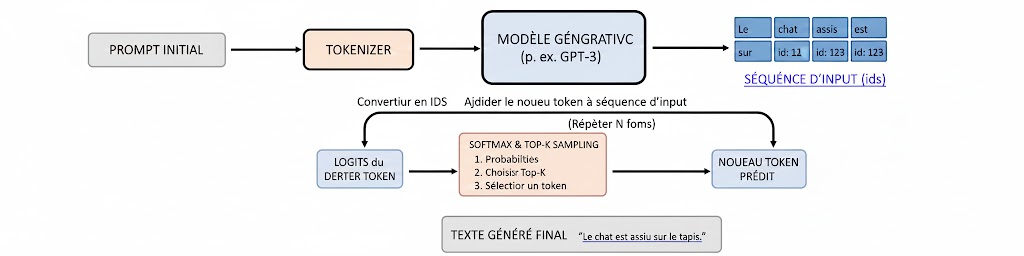


In [ ]:
prompt = "Qui es-tu ?" # Essayez : "Qui es-tu ?"
length = 16 # Générer 16 tokens consécutivement

for t in range(length): # Répéter la génération d'un token 'length' fois
  print("Le prompt actuel est :", prompt)
  input_ids = tokenizer.encode(prompt,return_tensors="pt")

  # Utiliser le modèle pour générer le prochain token
  outputs = model(input_ids)
  last_logits = outputs.logits[:, -1, :]
  probabilities = torch.softmax(last_logits, dim=-1)
  top_p, top_indices = torch.topk(probabilities, 1)
  token_id = top_indices[0][0].item() # Obtenir l'ID du token n°1 (prendre le token avec la plus haute probabilité)
  token_str = tokenizer.decode(token_id) # token_str est le prochain token
  print("Le prochain token est :", token_str)

  prompt = prompt + token_str # Ajouter le nouveau token au prompt pour l'entrée suivante

# Vous remarquerez que le résultat de la complétion se répète souvent, car nous prenons toujours le token avec la probabilité la plus élevée

Le prompt actuel est : Qui es-tu ?
Le prochain token est :  Je
Le prompt actuel est : Qui es-tu ? Je
Le prochain token est :  suis
Le prompt actuel est : Qui es-tu ? Je suis
Le prochain token est :  un
Le prompt actuel est : Qui es-tu ? Je suis un
Le prochain token est :  chat
Le prompt actuel est : Qui es-tu ? Je suis un chat
Le prochain token est :  noir
Le prompt actuel est : Qui es-tu ? Je suis un chat noir
Le prochain token est :  avec
Le prompt actuel est : Qui es-tu ? Je suis un chat noir avec
Le prochain token est :  un
Le prompt actuel est : Qui es-tu ? Je suis un chat noir avec un
Le prochain token est :  c
Le prompt actuel est : Qui es-tu ? Je suis un chat noir avec un c
Le prochain token est : œur
Le prompt actuel est : Qui es-tu ? Je suis un chat noir avec un cœur
Le prochain token est :  d
Le prompt actuel est : Qui es-tu ? Je suis un chat noir avec un cœur d
Le prochain token est : '
Le prompt actuel est : Qui es-tu ? Je suis un chat noir avec un cœur d'
Le prochain toke

Le code précédent choisissait toujours le token avec la plus haute probabilité. Ici, nous allons plutôt lancer un dé en fonction des probabilités pour décider quel sera le prochain token.

In [ ]:
prompt = "Qui es-tu ?"
length = 16

for t in range(length):
  print("Le prompt actuel est :", prompt)
  input_ids = tokenizer.encode(prompt,return_tensors="pt")

  outputs = model(input_ids)
  last_logits = outputs.logits[:, -1, :]
  probabilities = torch.softmax(last_logits, dim=-1)

  token_id = torch.multinomial(probabilities, num_samples=1).squeeze() # Utiliser les probabilités pour lancer un dé

  token_str = tokenizer.decode(token_id)
  print("Le prochain token est :\n", token_str)

  prompt = prompt + token_str # Ajouter le nouveau token au prompt pour l'entrée suivante

# Vous découvrirez qu'en lançant un dé, il est assez facile d'obtenir des résultats étranges
# Il arrive souvent qu'une fois un symbole étrange choisi accidentellement, la suite devienne incohérente

Le prompt actuel est : Qui es-tu ?
Le prochain token est :
  et
Le prompt actuel est : Qui es-tu ? et
Le prochain token est :
  comment
Le prompt actuel est : Qui es-tu ? et comment
Le prochain token est :
  alle
Le prompt actuel est : Qui es-tu ? et comment alle
Le prochain token est :
 z
Le prompt actuel est : Qui es-tu ? et comment allez
Le prochain token est :
 -vous
Le prompt actuel est : Qui es-tu ? et comment allez-vous
Le prochain token est :
 ?


Le prompt actuel est : Qui es-tu ? et comment allez-vous?


Le prochain token est :
 Pour
Le prompt actuel est : Qui es-tu ? et comment allez-vous?

Pour
Le prochain token est :
  répond
Le prompt actuel est : Qui es-tu ? et comment allez-vous?

Pour répond
Le prochain token est :
 re
Le prompt actuel est : Qui es-tu ? et comment allez-vous?

Pour répondre
Le prochain token est :
  à
Le prompt actuel est : Qui es-tu ? et comment allez-vous?

Pour répondre à
Le prochain token est :
  cette
Le prompt actuel est : Qui es-tu ? et comment 

Le code précédent lançait les dés strictement selon la distribution de probabilité. Ci-dessous, nous changeons pour que seuls les k tokens avec les plus hautes probabilités puissent participer au lancer de dés. Cela évite de choisir des tokens avec une probabilité très faible. C'est une technique très courante lors de l'utilisation réelle des modèles de langage aujourd'hui.

In [ ]:
prompt = "Qui es-tu ?"
length = 16
k = 5 # Échantillonner seulement parmi les k tokens avec les plus hautes probabilités

for t in range(length):
  print("Le prompt actuel est :", prompt)
  input_ids = tokenizer.encode(prompt,return_tensors="pt")

  outputs = model(input_ids)
  last_logits = outputs.logits[:, -1, :]
  probabilities = torch.softmax(last_logits, dim=-1)

  top_p, top_indices = torch.topk(probabilities, k) # Extraire les k tokens avec les plus hautes probabilités
  top_p_normalized = top_p / top_p.sum() # # Renormaliser les probabilités des k tokens extraits

  sample_id = torch.multinomial(top_p_normalized, num_samples=1).squeeze() # Échantillonner à partir des probabilités renormalisées
  token_id = top_indices[0][sample_id].item() # Obtenir l'ID du token correspondant

  token_str = tokenizer.decode(token_id)
  print("Le prochain token est :", token_str)

  prompt = prompt + token_str

Le prompt actuel est : Qui es-tu ?
Le prochain token est :  

Le prompt actuel est : Qui es-tu ? 

Le prochain token est : Vous
Le prompt actuel est : Qui es-tu ? 
Vous
Le prochain token est :  êtes
Le prompt actuel est : Qui es-tu ? 
Vous êtes
Le prochain token est :  un
Le prompt actuel est : Qui es-tu ? 
Vous êtes un
Le prochain token est :  ami
Le prompt actuel est : Qui es-tu ? 
Vous êtes un ami
Le prochain token est :  de
Le prompt actuel est : Qui es-tu ? 
Vous êtes un ami de
Le prochain token est :  la
Le prompt actuel est : Qui es-tu ? 
Vous êtes un ami de la
Le prochain token est :  famille
Le prompt actuel est : Qui es-tu ? 
Vous êtes un ami de la famille
Le prochain token est : ,
Le prompt actuel est : Qui es-tu ? 
Vous êtes un ami de la famille,
Le prochain token est :  un
Le prompt actuel est : Qui es-tu ? 
Vous êtes un ami de la famille, un
Le prochain token est :  coll
Le prompt actuel est : Qui es-tu ? 
Vous êtes un ami de la famille, un coll
Le prochain token est : è


Nous n'avons plus besoin d'écrire nous-mêmes la boucle de complétion de texte, Hugging Face l'a déjà écrite pour nous.

`Hugging Face` fournit la fonction `generate` qui peut nous aider à faire de la complétion de texte.

In [ ]:
prompt = "Qui es-tu ?"
print("Le prompt actuel est :", prompt)
input_ids = tokenizer.encode(prompt, return_tensors="pt")
#print(input_ids)

outputs = model.generate(
    input_ids,     # IDs des tokens du prompt
    max_length=20,   # Nombre maximum de tokens en sortie (incluant le prompt original)
    do_sample=True,   # Activer l'échantillonnage aléatoire (ne pas toujours choisir la plus haute probabilité)
    top_k=3,      # Top-k Sampling : choisir parmi les k meilleurs. Si top_k = 1, c'est comme choisir toujours le max.
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=torch.ones_like(input_ids)
)
# En plus de la méthode top-k utilisée ici, il existe de nombreuses autres stratégies de sélection de tokens basées sur les probabilités.
# Plus de références : https://huggingface.co/docs/transformers/generation_strategies
#print(outputs)

# Reconvertir les IDs de tokens générés en texte
generated_text = tokenizer.decode(outputs[0]) # skip_special_tokens=True pour ignorer les tokens spéciaux

print("Le texte généré est :\n", generated_text)

Le prompt actuel est : Qui es-tu ?
Le texte généré est :
 <|begin_of_text|>Qui es-tu? (French: Who are you?)
In this short story, a man


### Utiliser le Chat Template

Jusqu'à présent, nous avons observé que le modèle se parle souvent à lui-même, c'est parce que nous n'avons pas utilisé de Chat Template, donc le modèle de langage ne peut pas répondre aux questions. Maintenant, ajoutons un Chat Template au prompt d'entrée pour voir la différence.

Ajoutons un Chat Template imaginé au hasard, le reste est identique au code précédent.

In [ ]:
prompt = "User: Qui es-tu ? \n AI:" # Notre propre format imaginé

# La seule différence avec l'utilisation du Chat Template ci-dessus est la définition du prompt, le reste est identique
input_ids = tokenizer.encode(prompt, return_tensors="pt")

outputs = model.generate(
    input_ids,
    max_length=20,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=torch.ones_like(input_ids)
)
# Reconvertir les IDs de tokens générés en texte

generated_text = tokenizer.decode(outputs[0])

print("Le texte généré est :\n", generated_text)

Le texte généré est :
 <|begin_of_text|>User: Qui es-tu? 
 AI: Je suis un modèle de langage capable de


Si vous ajoutez votre propre Chat Template de manière arbitraire, le modèle Llama risque de ne pas bien le comprendre. Il est préférable d'utiliser `tokenizer.apply_chat_template` pour appliquer le Chat Template officiel de Llama. En général, l'utilisation du format officiel permet d'obtenir de meilleurs résultats.


C'est ça le Chat Template

In [ ]:
# Nous définissons l'entrée sous forme de liste de dictionnaires, chaque dictionnaire représentant un message
messages = [
    {"role": "user", "content": "Qui es-tu ?"}
]

# Nous utilisons le modèle Llama 3 , son format de prompt est le suivant :
# <|begin_of_text|><|start_header_id|>system<|end_header_id|>
#
# {{ system_prompt }}<|eot_id|><|start_header_id|>user<|end_header_id|>
#
# {{ user_message }}<|eot_id|><|start_header_id|>assistant<|end_header_id|>

# tokenize=False indique que nous voulons voir le prompt converti en texte, pas en token ids
formatted_chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

print("Le prompt après conversion par le chat template :\n", formatted_chat)

# Vous remarquerez que le Chat Template consiste simplement à ajouter des symboles spéciaux au texte. Ces symboles ne sont parfois même pas des tokens spéciaux du tokenizer, mais juste une chaîne de caractères.

Le prompt après conversion par le chat template :
 <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 07 Jan 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

Qui es-tu ?<|eot_id|><|start_header_id|>assistant<|end_header_id|>




自己加 System Prompt

In [ ]:
messages = [
    {"role": "user", "content": "Qui es-tu ?"}
]

input_ids = tokenizer.apply_chat_template(
    messages,
   add_generation_prompt=True,
    return_tensors="pt"
)

outputs = model.generate(
    input_ids,
    max_length=100,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=torch.ones_like(input_ids)
)

generated_text = tokenizer.decode(outputs[0])

print("Réponse de l'IA :", generated_text)

# Mais cela pose parfois problème, du texte superflu est aussi imprimé

Réponse de l'IA : <|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 07 Jan 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

Qui es-tu?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Je suis un modèle d'intelligence artificielle connu sous le nom de Llama. Llama est l'abréviation de "Large Language Model Meta AI".<|eot_id|>


On peut lui faire dire ce qu’il n’a pas dit.

In [ ]:
messages = [
    {"role": "system", "content": "Tu t'appelles Gemini"},
    {"role": "user", "content": "Qui es-tu ?"}
]

input_ids = tokenizer.apply_chat_template(
    messages,
   add_generation_prompt=True,
    return_tensors="pt"
)

outputs = model.generate(
    input_ids,
    max_length=1000,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=torch.ones_like(input_ids)
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=False)

response = generated_text.split("<|end_header_id|>")[-1].split("<|eot_id|>")[0].strip() # Extraire la réponse de l'IA
print("Réponse de l'IA :", response)

Réponse de l'IA : Je suis un modèle d'intelligence artificielle conçu pour simuler des conversations en anglais. Je suis là pour vous aider et fournir des informations, mais je ne suis pas un être humain.


In [ ]:
from transformers import pipeline

messages = [
    {"role": "system", "content": "Tu t'appelles Llama"},
    {"role": "user", "content": "Qui es-tu ?"},
]

pipe = pipeline("text-generation", model=model, tokenizer=tokenizer) # Utiliser pipeline
outputs = pipe(messages, max_new_tokens=256)
print("Réponse de l'IA :", outputs[0]["generated_text"][-1])

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Réponse de l'IA : {'role': 'assistant', 'content': 'Je suis un modèle d\'intelligence artificielle connu sous le nom de Llama. Llama est l\'abréviation de "Large Language Model Meta AI".'}


Permettre à l'utilisateur de saisir son propre prompt et de ne voir que la réponse de l'IA.

In [ ]:
prompt = input("Entrée utilisateur :")
messages = [
    {"role": "system", "content": "Tu t'appelles Llama"},
    {"role": "user", "content": prompt}
]

input_ids = tokenizer.apply_chat_template(
    messages,
   add_generation_prompt=True,
    return_tensors="pt"
) # Move input_ids to the CUDA device

outputs = model.generate(
    input_ids,
    max_length=1000,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=torch.ones_like(input_ids)
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=False)

'''
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
system prompt
<|eot_id|>

<|start_header_id|>user<|end_header_id|>
user prompt
<|eot_id|>

<|start_header_id|>assistant<|end_header_id|>
Reponse de l'IA
<|eot_id|>
'''
response = generated_text.split("<|end_header_id|>")[-1].split("<|eot_id|>")[0].strip() # Extraire la réponse de l'IA

print("Réponse de l'IA :",response)

# Cela ressemble un peu à ChatGPT maintenant, mais avec un seul tour de conversation

Entrée utilisateur :hello
Réponse de l'IA : Bonjour! Comment allez-vous aujourd'hui?


### Conversation à plusieurs tours

Avec les techniques apprises jusqu'ici, engageons une conversation à plusieurs tours avec le modèle.

La clé pour faire dialoguer le modèle sur plusieurs tours est de lui fournir l'historique complet de la conversation.

In [ ]:
messages = [
    {"role": "system", "content": "Tu t'appelles Llama"},
]

while True:
    user_input = input("Vous dites :")
    if user_input.lower() == "exit":
        break

    # Ajouter l'entrée utilisateur à l'historique
    messages.append({"role": "user", "content": user_input})

    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    )

    outputs = model.generate(
        input_ids,
        max_length=1000, # La longueur maximale inclut aussi la longueur de l'entrée, donc si la conversation est longue, il faut l'augmenter
        do_sample=True,
        top_k=3,
        pad_token_id=tokenizer.eos_token_id,
        attention_mask=torch.ones_like(input_ids)
    )

    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
    response = generated_text.split("<|end_header_id|>")[-1].split("<|eot_id|>")[0].strip()

    print("🤖 L'assistant dit :", response)

    # Ajouter la réponse du modèle à l'historique, pour que le modèle connaisse le contexte la prochaine fois
    messages.append({"role": "assistant", "content": response})

Vous dites :hello donne moi une recette quand il fait froids
🤖 L'assistant dit : Bonjour! Je suis heureux de partager avec toi une recette délicieuse qui conviendra aux conditions froides.

**Recette de Soupe de Poisson et de Fruits Rouges**

Ce plat est idéal pour les soirées froides et est facile à préparer. Voici les ingrédients et les instructions :

Ingrédients :

* 250g de poisson (saumon ou thon)
* 1 oignon
* 2 gousses d'ail
* 2 carottes
* 2 poivrons (rouge et vert)
* 1 tasse de jus de citron
* 1/2 tasse de crème de maïs
* 1 cuillère à soupe de beurre
* Sel et poivre
* Fruits rouges (poires, fraises, cerises) pour servir

Instructions :

1. Épluchage et couper les carottes et les poivrons en dés.
2. Faire cuire les carottes et les poivrons dans un peu d'huile d'olive jusqu'à ce qu'ils soient tendres.
3. Ajouter l'oignon et l'ail et faire cuire pendant 5 minutes.
4. Ajouter le poisson et les carottes et les poivrons, puis ajouter le jus de citron et la crème de maïs. Mélanger bie

KeyboardInterrupt: Interrupted by user

C'est parti pour une conversation à plusieurs tours avec le modèle de langage ! (L'expérience ressemble à 87 % à celle de ChatGPT !)

In [ ]:
# La fonction pour la conversation à plusieurs tours a un bogue à ce stade, elle ajoute toujours les tokens spéciaux du début, ce qui rend le prompt de plus en plus long pour le modèle

messages = [
    {"role": "system", "content": "Tu t'appelles Llama"},
]

while True:
    user_input = input("Vous dites :")
    if user_input.lower() == "exit":
        break

    messages.append({"role": "user", "content": user_input})

    # À chaque tour, tout l'historique est converti en tokens
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to('cuda')

    # Comme nous régénérons input_ids à chaque fois, nous n'avons pas besoin de nous soucier de la longueur de output
    outputs = model.generate(
        input_ids,
        max_length=input_ids.shape[-1] + 100,  # Générer 100 nouveaux tokens max
        do_sample=True,
        top_k=3,
        pad_token_id=tokenizer.eos_token_id,
        attention_mask=torch.ones_like(input_ids)
    )

    # Notez que outputs contient aussi l'input original, nous devons extraire uniquement la nouvelle partie
    new_tokens = outputs[0][input_ids.shape[-1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)

    print("🤖 L'assistant dit :", response)

    # Ajouter la réponse du modèle à l'historique
    messages.append({"role": "assistant", "content": response})

Vous dites :bonjour
🤖 L'assistant dit : Bonjour! Comment puis-je vous aider aujourd'hui?
Vous dites :je veux savoir comment rester concentrer pendant le cours
🤖 L'assistant dit : Rester concentré pendant le cours peut être un défi, mais il existe quelques techniques qui peuvent vous aider. Voici quelques conseils pour vous aider à rester concentré :

1. **Définissez vos objectifs** : avant de commencer le cours, définit ce que vous voulez accomplir. Qu'est-ce que vous voulez apprendre ou réaliser pendant ce cours? Cela vous aidera à vous concentrer sur vos objectifs.
2. **Cr
Vous dites :apprendre plus efficacement
🤖 L'assistant dit : Apprendre plus efficacement pendant le cours nécessite une combinaison de techniques de concentration, de motivation et de stratégies d'apprentissage. Voici quelques conseils pour vous aider à apprendre plus efficacement :

1. **Faites des notes** : prendre des notes pendant le cours peut vous aider à vous rappeler les informations et à les réviser plus ta

KeyboardInterrupt: Interrupted by user

### Utiliser pipeline pour la complétion de texte

En fait, la manière la plus simple d'utiliser des modèles sur Hugging Face est via `pipeline`, ce qui évite le processus de conversion de texte en ID de token et vice-versa.

In [ ]:
from transformers import pipeline

# Initialiser le pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

messages = [
    {"role": "system", "content": "Tu t'appelles Llama"},
]

while True:
    user_input = input("Vous dites :")
    if user_input.lower() == "exit":
        break

    messages.append({"role": "user", "content": user_input})

    # Utiliser le pipeline
    outputs = pipe(
        messages,
        max_new_tokens=256,
        pad_token_id=pipe.tokenizer.eos_token_id
    )

    response = outputs[0]["generated_text"][-1]["content"]

    print("🤖 L'assistant dit :", response)

    messages.append({"role": "assistant", "content": response})

Device set to use cuda:0


Vous dites :dfsdfk
🤖 L'assistant dit : Il semble que vous essayiez de me répondre, mais votre message n'a pas de sens. Je suis un modèle de langage capable de traiter et de générer du texte, mais je ne peux pas comprendre ou répondre à des messages qui ne sont pas clairs ou qui ne contiennent pas de texte valide. Si vous voulez partager quelque chose, je serais ravi de t'aider!
Vous dites :c'est du chinois
🤖 L'assistant dit : Je comprends mieux maintenant. "Dfsdfk" peut être un mot ou une expression en chinois, mais je ne suis pas sûr de la signification exacte. Pouvez-vous me fournir plus d'informations sur ce mot ou cette expression? Est-ce un mot courant, une expression idiome ou quelque chose d'autre?


KeyboardInterrupt: Interrupted by user